## **Install Required Libraries**

In [1]:
# Uncomment if running in a fresh environment
# !pip install shap -q
print("✅ Libraries ready.")

✅ Libraries ready.


## **Imports and Configuration**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve, precision_score, recall_score
)

# ============================================================
# CONFIGURATION – Medical thresholds (can be adjusted)
# ============================================================
THRESHOLDS = {
    'cholesterol_high': 200,      # mg/dL – used for mapping
    'glucose_high': 100,           # mg/dL
    'bp_systolic_high': 140,       # mmHg
    'bp_diastolic_high': 90,       # mmHg
    'bmi_overweight': 25,
    'bmi_obese': 30,
    'age_risk': 50
}

print("✅ Imports and configuration complete.")

✅ Imports and configuration complete.


## **Load and Clean cardio_train.csv**

In [3]:
# Load data
df = pd.read_csv('cardio_train.csv', sep=';')
print(f"Original dataset shape: {df.shape}")

# Drop id
df.drop('id', axis=1, inplace=True)

# Convert age to years
df['age_years'] = df['age'] / 365.25

# Ensure binary columns are integer
binary_cols = ['gender', 'smoke', 'alco', 'active', 'cardio']
df.dropna(subset=['cardio'], inplace=True)
for col in binary_cols:
    df[col] = df[col].astype(int)

print("✅ Data loaded and cleaned.")

Original dataset shape: (70000, 13)
✅ Data loaded and cleaned.


## **Outlier Removal (Medical Plausibility)**

In [4]:
initial_len = len(df)

# Blood pressure constraints
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] > df['ap_lo']]          # systolic > diastolic

# Height and weight constraints
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print(f"Rows removed: {initial_len - len(df)} ({initial_len - len(df):.1%} outliers)")
print(f"Final dataset shape: {df.shape}")

Rows removed: 1383 (138300.0% outliers)
Final dataset shape: (68617, 13)


## **Basic Feature Engineering**

In [5]:
# BMI
df['height_m'] = df['height'] / 100
df['BMI'] = df['weight'] / (df['height_m'] ** 2)

# Hypertension flags
df['high_ap_hi'] = (df['ap_hi'] >= THRESHOLDS['bp_systolic_high']).astype(int)
df['high_ap_lo'] = (df['ap_lo'] >= THRESHOLDS['bp_diastolic_high']).astype(int)

# Cholesterol & glucose flags (2 or 3 = above normal)
df['high_cholesterol'] = (df['cholesterol'] >= 2).astype(int)
df['high_gluc'] = (df['gluc'] >= 2).astype(int)

# Weight status
df['overweight'] = (df['BMI'] >= THRESHOLDS['bmi_overweight']).astype(int)
df['obese'] = (df['BMI'] >= THRESHOLDS['bmi_obese']).astype(int)

# Composite risk score (sum of selected binary flags)
df['risk_score'] = (
    df['high_ap_hi'] + df['high_ap_lo'] + df['high_cholesterol'] +
    df['high_gluc'] + df['overweight'] + df['smoke'] + df['alco']
)

print("✅ Basic features engineered.")

✅ Basic features engineered.


## **Exploratory Data Analysis (EDA)**


EXPLORATORY DATA ANALYSIS

📊 Summary Statistics (after cleaning):
          age_years           BMI         ap_hi         ap_lo   cholesterol  \
count  68617.000000  68617.000000  68617.000000  68617.000000  68617.000000   
mean      53.291864     27.473368    126.679657     81.320154      1.364720   
std        6.756781      5.351060     16.686884      9.429777      0.678933   
min       29.563313     10.726644     80.000000     50.000000      1.000000   
25%       48.344969     23.875115    120.000000     80.000000      1.000000   
50%       53.941136     26.346494    120.000000     80.000000      1.000000   
75%       58.381930     30.119376    140.000000     90.000000      2.000000   
max       64.922656    152.551775    240.000000    182.000000      3.000000   

               gluc  
count  68617.000000  
mean       1.225775  
std        0.571646  
min        1.000000  
25%        1.000000  
50%        1.000000  
75%        1.000000  
max        3.000000  


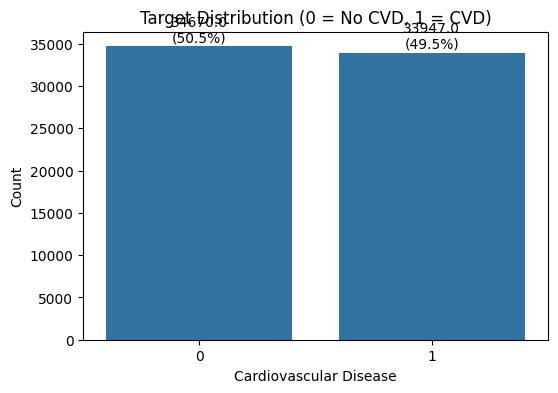

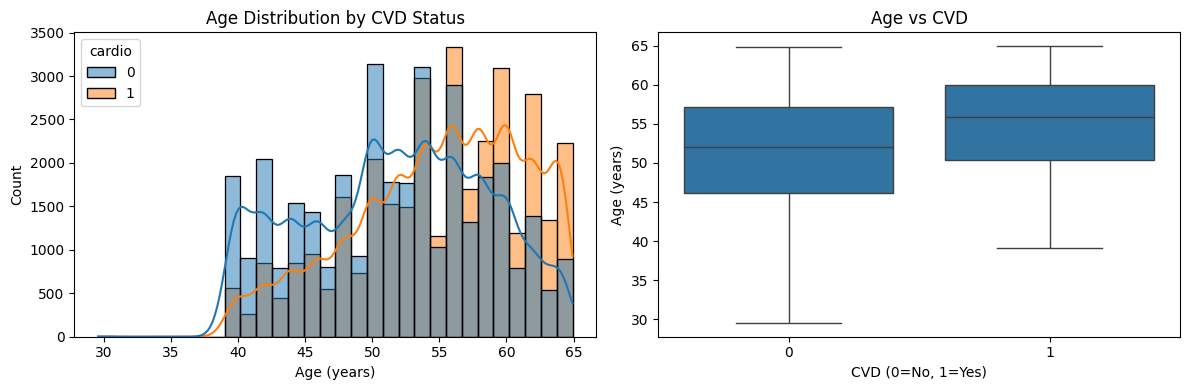

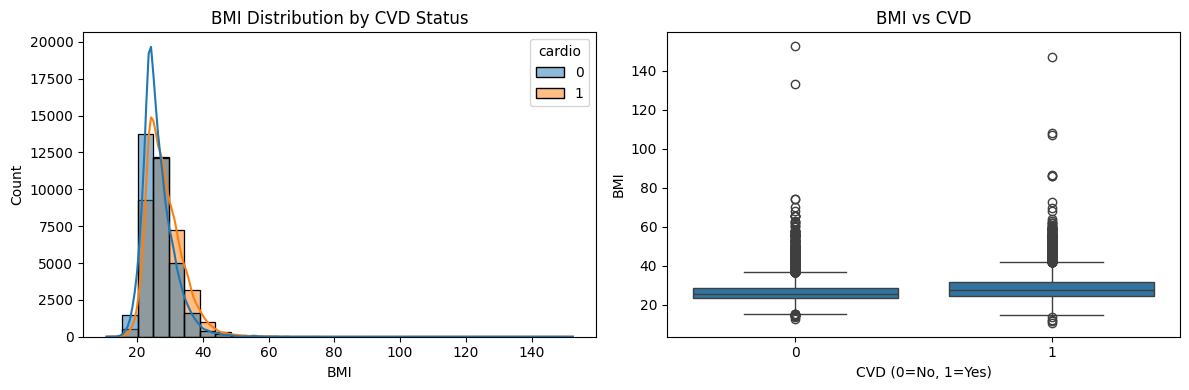

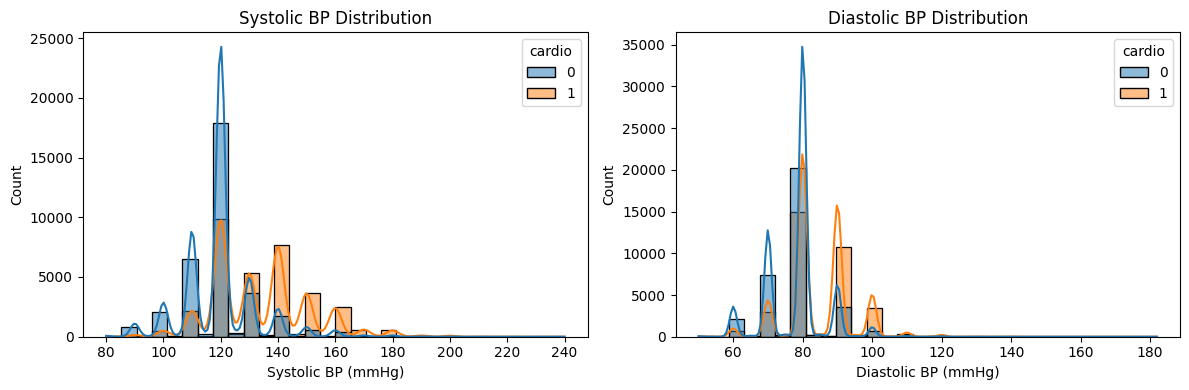

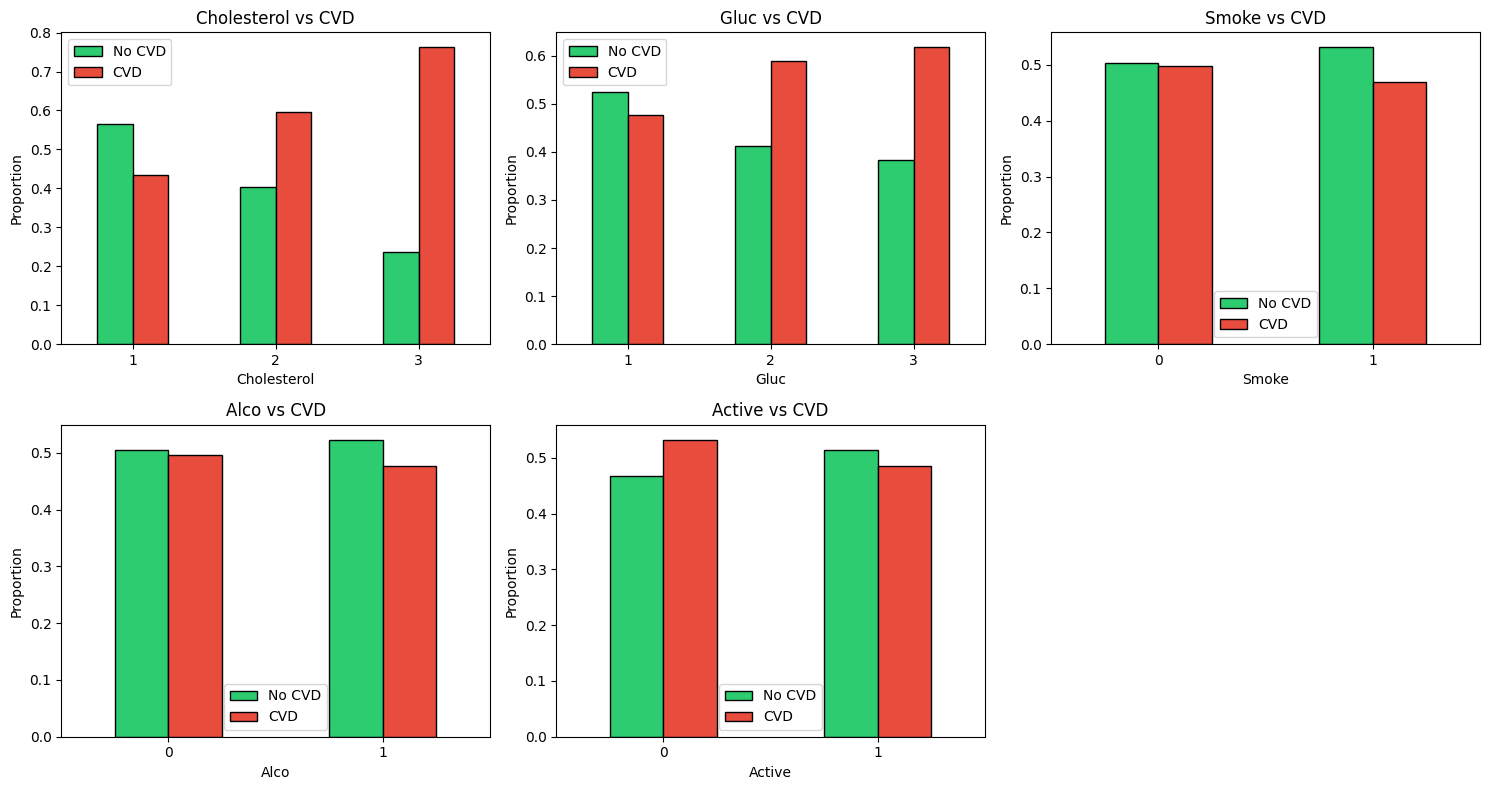

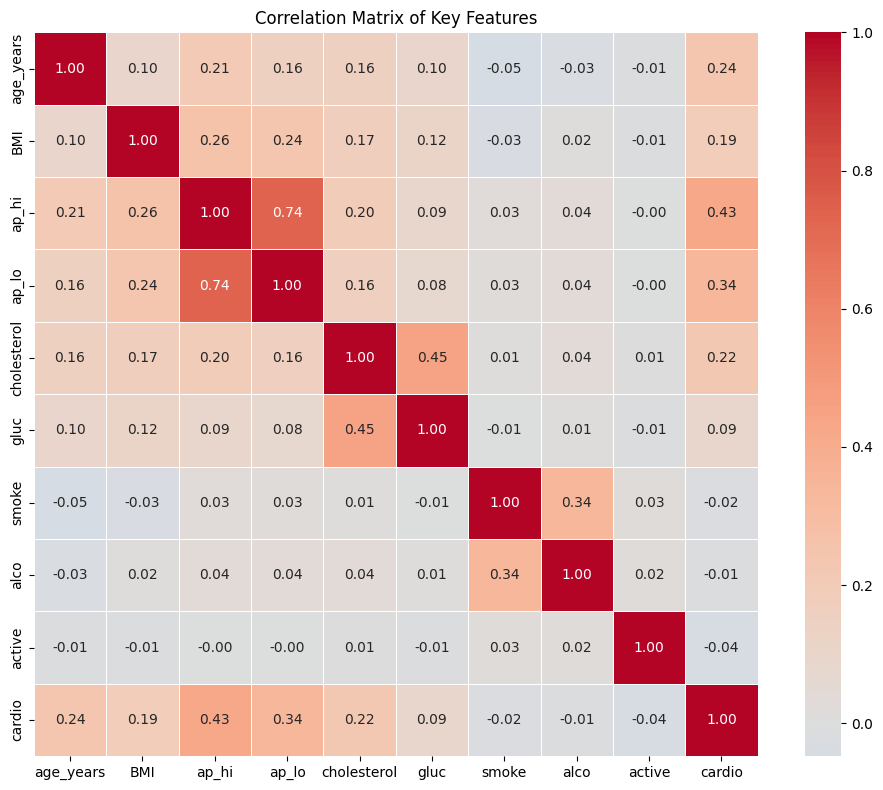


✅ EDA complete. Insights:
  • The dataset is balanced (target ~50/50).
  • CVD patients tend to be older and have higher BMI.
  • High cholesterol and glucose levels are more prevalent in CVD group.
  • Smoking and alcohol consumption show modest association with CVD.


In [24]:
## **Exploratory Data Analysis (EDA)**

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Summary statistics of key features
print("\n📊 Summary Statistics (after cleaning):")
print(df[['age_years', 'BMI', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc']].describe())

# 2. Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title('Target Distribution (0 = No CVD, 1 = CVD)')
plt.xlabel('Cardiovascular Disease')
plt.ylabel('Count')
for i, p in enumerate(plt.gca().patches):
    plt.text(p.get_x() + p.get_width()/2., p.get_height() + 500,
             f'{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)',
             ha='center', fontsize=10)
plt.show()

# 3. Age distribution by target
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(data=df, x='age_years', hue='cardio', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution by CVD Status')
axes[0].set_xlabel('Age (years)')
sns.boxplot(data=df, x='cardio', y='age_years', ax=axes[1])
axes[1].set_title('Age vs CVD')
axes[1].set_xlabel('CVD (0=No, 1=Yes)')
axes[1].set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

# 4. BMI distribution by target
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(data=df, x='BMI', hue='cardio', bins=30, kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution by CVD Status')
sns.boxplot(data=df, x='cardio', y='BMI', ax=axes[1])
axes[1].set_title('BMI vs CVD')
axes[1].set_xlabel('CVD (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

# 5. Blood pressure distribution
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(data=df, x='ap_hi', hue='cardio', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Systolic BP Distribution')
axes[0].set_xlabel('Systolic BP (mmHg)')
sns.histplot(data=df, x='ap_lo', hue='cardio', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Diastolic BP Distribution')
axes[1].set_xlabel('Diastolic BP (mmHg)')
plt.tight_layout()
plt.show()

# 6. Categorical features analysis
categorical_vars = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()
for i, var in enumerate(categorical_vars):
    pd.crosstab(df[var], df['cardio'], normalize='index').plot(kind='bar',
                                                                ax=axes[i],
                                                                color=['#2ecc71','#e74c3c'],
                                                                edgecolor='black')
    axes[i].set_title(f'{var.capitalize()} vs CVD')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['No CVD', 'CVD'])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
# Remove empty subplot
if len(categorical_vars) < len(axes):
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# 7. Correlation heatmap (numerical features)
numerical_cols = ['age_years', 'BMI', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
                  'smoke', 'alco', 'active', 'cardio']
plt.figure(figsize=(10,8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

print("\n✅ EDA complete. Insights:")
print("  • The dataset is balanced (target ~50/50).")
print("  • CVD patients tend to be older and have higher BMI.")
print("  • High cholesterol and glucose levels are more prevalent in CVD group.")
print("  • Smoking and alcohol consumption show modest association with CVD.")

## **Add Realistic Synthetic Lifestyle Columns**

In [6]:
np.random.seed(42)
n = len(df)

# -----------------------------------------------------------------
# Diabetes – correlate with glucose, age, BMI
# -----------------------------------------------------------------
glucose_risk = (df['gluc'] > 2).astype(int)      # gluc=3 (high)
age_risk = (df['age_years'] > THRESHOLDS['age_risk']).astype(int)
bmi_risk = (df['BMI'] > THRESHOLDS['bmi_obese']).astype(int)
diabetes_prob = 0.05 + 0.3*glucose_risk + 0.1*age_risk + 0.1*bmi_risk
df['Diabetes'] = (np.random.random(n) < diabetes_prob).astype(int)

# -----------------------------------------------------------------
# Family history – independent (approx. 25% prevalence)
# -----------------------------------------------------------------
df['Family_History'] = np.random.choice([0, 1], n, p=[0.75, 0.25])

# -----------------------------------------------------------------
# Stress level – independent (categorical)
# -----------------------------------------------------------------
stress_options = ['Low', 'Medium', 'High']
stress_probs = [0.3, 0.5, 0.2]
df['Stress_Level'] = np.random.choice(stress_options, n, p=stress_probs)

# -----------------------------------------------------------------
# Sleep hours – normally distributed
# -----------------------------------------------------------------
df['Sleep_Hours'] = np.clip(np.random.normal(7, 1.5, n), 4, 10).round(1)

# -----------------------------------------------------------------
# Physical activity – derived from 'active' column
# -----------------------------------------------------------------
def map_activity(active):
    if active == 0:
        return np.random.choice(['Sedentary','Moderate'], p=[0.8,0.2])
    else:
        return np.random.choice(['Moderate','Active'], p=[0.6,0.4])

df['Physical_Activity'] = df['active'].apply(map_activity)

# -----------------------------------------------------------------
# Alcohol – derived from 'alco' column
# -----------------------------------------------------------------
def map_alcohol(alco):
    if alco == 0:
        return 'None'
    else:
        return np.random.choice(['Light','Heavy'], p=[0.7,0.3])

df['Alcohol'] = df['alco'].apply(map_alcohol)

# -----------------------------------------------------------------
# Years smoking – only if smoker
# -----------------------------------------------------------------
df['Years_Smoking'] = 0
smoker_idx = df['smoke'] == 1
df.loc[smoker_idx, 'Years_Smoking'] = np.random.randint(1, 35, size=smoker_idx.sum())

# -----------------------------------------------------------------
# Exercise hours/week – derived from 'active'
# -----------------------------------------------------------------
df['Exercise hours/week'] = np.where(
    df['active'] == 1,
    np.random.uniform(2, 7, n),
    np.random.uniform(0, 3, n)
).round(1)

print("✅ Realistic synthetic lifestyle columns added.")

✅ Realistic synthetic lifestyle columns added.


## **Encode Categorical Columns**

In [7]:
categorical_cols = ['Stress_Level', 'Physical_Activity', 'Alcohol']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    encoders[col] = le

# Gender is already numeric (1=female, 2=male) – we keep as is.
print("✅ Encoders fitted for categorical columns.")

✅ Encoders fitted for categorical columns.


## **Define Final Feature Set**

In [8]:
GATEWAY_FEATURES = [
    'age_years',               # Age in years
    'gender',                   # 1=female, 2=male
    'height',
    'weight',
    'BMI',
    'ap_hi',
    'ap_lo',
    'cholesterol',              # 1=normal, 2=above normal, 3=well above
    'gluc',                     # same scale
    'smoke',
    'alco',
    'active',
    'high_ap_hi',
    'high_ap_lo',
    'high_cholesterol',
    'high_gluc',
    'overweight',
    'obese',
    'risk_score',
    'Diabetes',
    'Family_History',
    'Stress_Level_Encoded',
    'Sleep_Hours',
    'Physical_Activity_Encoded',
    'Alcohol_Encoded',
    'Years_Smoking',
    'Exercise hours/week'
]

X = df[GATEWAY_FEATURES]
y = df['cardio']   # target

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Feature matrix shape: (68617, 27)
Target distribution:
cardio
0    0.505268
1    0.494732
Name: proportion, dtype: float64


## **Train/Test Split and Scaling**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 51462, Test samples: 17155


## **Train Random Forest Classifier (Regularised)**

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("✅ Random Forest model trained.")

✅ Random Forest model trained.


## **Model Evaluation – Metrics & Classification Report**


MODEL PERFORMANCE
Metric                    Train       Test        Gap
--------------------------------------------------
Accuracy                  0.763      0.734      0.028
F1-Score                  0.745      0.714      0.031
ROC-AUC                   0.843      0.800      0.043

Classification Report (Test Set):
              precision    recall  f1-score   support

      No CVD       0.71      0.80      0.75      8668
         CVD       0.77      0.67      0.71      8487

    accuracy                           0.73     17155
   macro avg       0.74      0.73      0.73     17155
weighted avg       0.74      0.73      0.73     17155


Confusion Matrix (Test Set):
[[6928 1740]
 [2815 5672]]


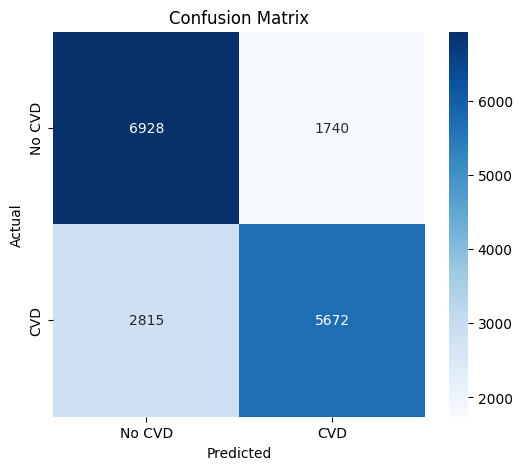

In [11]:
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)
y_train_proba = rf_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"{'Metric':<20} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-"*50)
print(f"{'Accuracy':<20} {train_acc:>10.3f} {test_acc:>10.3f} {abs(train_acc-test_acc):>10.3f}")
print(f"{'F1-Score':<20} {train_f1:>10.3f} {test_f1:>10.3f} {abs(train_f1-test_f1):>10.3f}")
print(f"{'ROC-AUC':<20} {train_auc:>10.3f} {test_auc:>10.3f} {abs(train_auc-test_auc):>10.3f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['No CVD', 'CVD']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CVD', 'CVD'],
            yticklabels=['No CVD', 'CVD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **ROC Curve and Optimal Threshold**

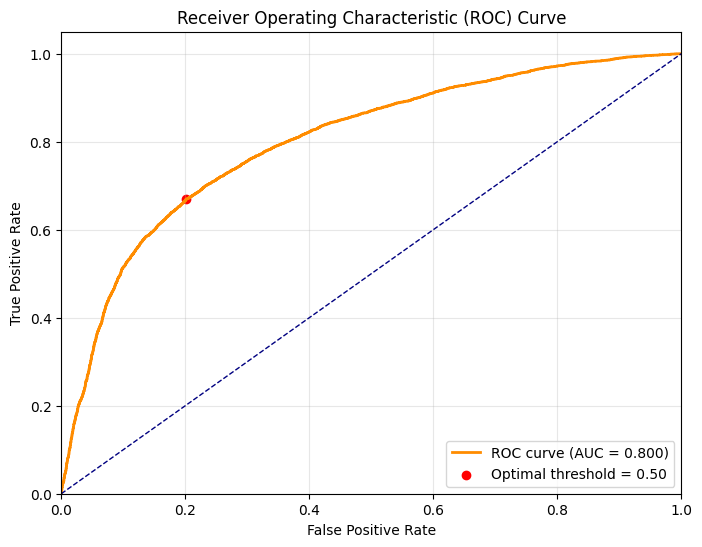

Optimal threshold (Youden index): 0.499


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red',
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"Optimal threshold (Youden index): {optimal_threshold:.3f}")

## **Cross‑Validation**

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(rf_model, X, y, cv=cv, scoring='f1')

print("\n" + "="*60)
print("CROSS‑VALIDATION (5‑fold)")
print("="*60)
print(f"Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"F1-score: {cv_f1.mean():.3f} (+/- {cv_f1.std():.3f})")


CROSS‑VALIDATION (5‑fold)
Accuracy: 0.732 (+/- 0.002)
F1-score: 0.711 (+/- 0.002)


## **Feature Importance and SHAP Global Explanation**

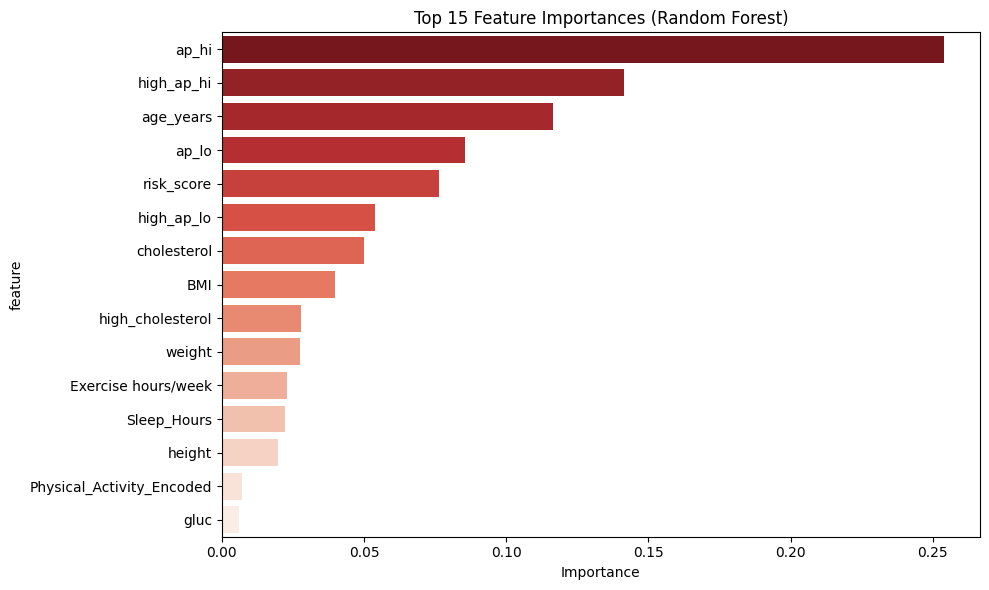

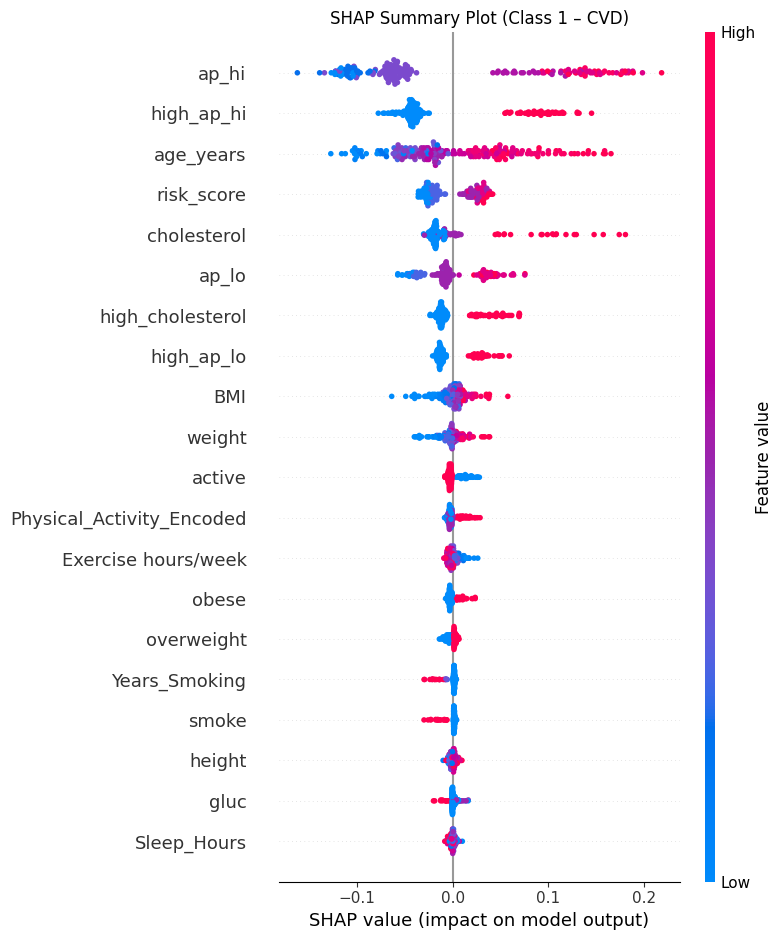

In [14]:
# Built‑in importance
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'feature': GATEWAY_FEATURES, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='Reds_r')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# SHAP global explanation
explainer = shap.TreeExplainer(rf_model)
X_test_sample = X_test_scaled[:200]   # sample for speed
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values[:, :, 1], X_test_sample, feature_names=GATEWAY_FEATURES, show=False)
plt.title('SHAP Summary Plot (Class 1 – CVD)')
plt.tight_layout()
plt.show()

## **Input Validation Functions**

In [15]:
class InputValidationError(Exception):
    """Custom exception for input validation errors"""
    pass

def validate_and_convert_input(value, field_name, expected_type, valid_options=None,
                                min_val=None, max_val=None, pattern=None):
    """
    Validates and converts a single input with helpful error messages.
    """
    if isinstance(value, str):
        value = value.strip()
        if value == '':
            raise InputValidationError(f"{field_name} cannot be empty.")

    # Choice validation
    if expected_type == 'choice' and valid_options:
        value_lower = value.lower()
        valid_lower = [opt.lower() for opt in valid_options]
        if value_lower not in valid_lower:
            options_str = ', '.join([f"'{opt}'" for opt in valid_options])
            raise InputValidationError(
                f"Invalid input for {field_name}: '{value}'. "
                f"Accepted values: {options_str}"
            )
        idx = valid_lower.index(value_lower)
        return valid_options[idx]

    # Numeric validation
    if expected_type in ['int', 'float']:
        try:
            converted = float(value) if expected_type == 'float' else int(float(value))
        except ValueError:
            raise InputValidationError(f"{field_name} must be a number. You entered '{value}'.")
        if min_val is not None and converted < min_val:
            raise InputValidationError(f"{field_name} is too low (min {min_val}).")
        if max_val is not None and converted > max_val:
            raise InputValidationError(f"{field_name} is too high (max {max_val}).")
        return converted

    # Pattern validation (e.g., blood pressure)
    if expected_type == 'pattern' and pattern:
        if not re.match(pattern, value):
            raise InputValidationError(f"Invalid format for {field_name}. Expected pattern: {pattern}")
        return value

    return value

def get_validated_input(prompt, field_name, expected_type, **kwargs):
    """Repeatedly asks until valid input is given."""
    while True:
        try:
            user_input = input(prompt)
            result = validate_and_convert_input(user_input, field_name, expected_type, **kwargs)
            return result
        except InputValidationError as e:
            print(f"  ✗ {e}\n  Please try again.\n")

Interactive Questionnaire

In [16]:
def interactive_questionnaire():
    """Full questionnaire with validation."""
    print("\n" + "="*60)
    print(" CAD RISK SCREENING – PATIENT QUESTIONNAIRE")
    print("="*60)
    print("Please answer all questions carefully.\n")

    raw = {}

    # Basic info
    print("📋 Basic Information")
    raw['age'] = get_validated_input("Age (years): ", "Age", 'int', min_val=18, max_val=120)
    raw['gender'] = get_validated_input("Gender (Male/Female): ", "Gender", 'choice',
                                        valid_options=['Male', 'Female'])

    # Body measurements
    print("\n📋 Body Measurements")
    raw['height_cm'] = get_validated_input("Height (cm): ", "Height", 'float', min_val=50, max_val=250)
    raw['weight_kg'] = get_validated_input("Weight (kg): ", "Weight", 'float', min_val=20, max_val=300)

    # Clinical measurements
    print("\n📋 Clinical Measurements")
    raw['blood_pressure'] = get_validated_input(
        "Blood Pressure (e.g., 120/80): ", "Blood Pressure", 'pattern',
        pattern=r'^\d{2,3}/\d{2,3}$'
    )
    # Additional BP validation
    try:
        sys, dia = map(int, raw['blood_pressure'].split('/'))
        if not (60 <= sys <= 250 and 40 <= dia <= 150) or sys <= dia:
            print("  ✗ Invalid blood pressure values (systolic must be > diastolic and within reasonable range).")
            raw['blood_pressure'] = get_validated_input(
                "Blood Pressure (e.g., 120/80): ", "Blood Pressure", 'pattern',
                pattern=r'^\d{2,3}/\d{2,3}$'
            )
    except:
        pass   # pattern already ensures format

    raw['cholesterol'] = get_validated_input("Cholesterol (mg/dL): ", "Cholesterol", 'int',
                                             min_val=100, max_val=600)
    raw['glucose'] = get_validated_input("Glucose (mg/dL): ", "Glucose", 'int',
                                         min_val=50, max_val=600)

    # Lifestyle factors
    print("\n📋 Lifestyle Factors")
    raw['smoker'] = get_validated_input("Do you smoke? (Yes/No): ", "Smoking status", 'choice',
                                        valid_options=['Yes', 'No'])
    if raw['smoker'] == 'Yes':
        raw['years_smoking'] = get_validated_input("Years of smoking: ", "Years smoking", 'int',
                                                   min_val=1, max_val=raw['age'] - 10)
    else:
        raw['years_smoking'] = 0

    raw['diabetes'] = get_validated_input("Diabetes? (Yes/No): ", "Diabetes status", 'choice',
                                          valid_options=['Yes', 'No'])
    raw['alcohol'] = get_validated_input("Alcohol consumption (None/Light/Heavy): ", "Alcohol", 'choice',
                                         valid_options=['None', 'Light', 'Heavy'])
    raw['physical_activity'] = get_validated_input("Physical Activity (Sedentary/Moderate/Active): ",
                                                   "Physical Activity", 'choice',
                                                   valid_options=['Sedentary', 'Moderate', 'Active'])
    raw['family_history'] = get_validated_input("Family history of CAD? (Yes/No): ", "Family history", 'choice',
                                                valid_options=['Yes', 'No'])
    raw['stress_level'] = get_validated_input("Stress Level (Low/Medium/High): ", "Stress level", 'choice',
                                              valid_options=['Low', 'Medium', 'High'])
    raw['sleep_hours'] = get_validated_input("Sleep hours per night: ", "Sleep hours", 'float',
                                             min_val=0, max_val=24)
    raw['exercise_hours'] = get_validated_input("Exercise hours per week: ", "Exercise hours", 'float',
                                                min_val=0, max_val=168)

    print("\n✅ Questionnaire complete. Processing...")
    return raw

## **Map User Input to Gateway Features**

In [17]:
def map_raw_to_gateway(raw):
    """Convert raw questionnaire answers to feature dict matching GATEWAY_FEATURES."""
    # Extract BP
    systolic, diastolic = map(int, raw['blood_pressure'].split('/'))

    # Height in meters, BMI
    height_m = raw['height_cm'] / 100
    bmi = raw['weight_kg'] / (height_m ** 2)

    # Derived flags using same thresholds as training
    high_ap_hi = 1 if systolic >= THRESHOLDS['bp_systolic_high'] else 0
    high_ap_lo = 1 if diastolic >= THRESHOLDS['bp_diastolic_high'] else 0
    high_chol = 1 if raw['cholesterol'] > THRESHOLDS['cholesterol_high'] else 0
    high_gluc = 1 if raw['glucose'] > THRESHOLDS['glucose_high'] else 0
    overweight = 1 if bmi >= THRESHOLDS['bmi_overweight'] else 0
    obese = 1 if bmi >= THRESHOLDS['bmi_obese'] else 0

    # Risk score (same definition as training)
    risk_score = sum([
        high_ap_hi,
        high_ap_lo,
        high_chol,
        high_gluc,
        overweight,
        1 if raw['smoker'] == 'Yes' else 0,
        1 if raw['alcohol'] != 'None' else 0
    ])

    # Encode categoricals using fitted encoders
    stress_enc = encoders['Stress_Level'].transform([raw['stress_level']])[0]
    activity_enc = encoders['Physical_Activity'].transform([raw['physical_activity']])[0]
    alcohol_enc = encoders['Alcohol'].transform([raw['alcohol']])[0]

    # Build feature dictionary
    feature_dict = {
        'age_years': raw['age'],
        'gender': 2 if raw['gender'] == 'Male' else 1,   # 1=female, 2=male
        'height': raw['height_cm'],
        'weight': raw['weight_kg'],
        'BMI': bmi,
        'ap_hi': systolic,
        'ap_lo': diastolic,
        'cholesterol': 3 if high_chol else 1,   # mapping: 1=normal, 3=high (ignore 2 for simplicity)
        'gluc': 3 if high_gluc else 1,
        'smoke': 1 if raw['smoker'] == 'Yes' else 0,
        'alco': 1 if raw['alcohol'] != 'None' else 0,
        'active': 2 if raw['physical_activity'] == 'Active' else (1 if raw['physical_activity'] == 'Moderate' else 0),
        'high_ap_hi': high_ap_hi,
        'high_ap_lo': high_ap_lo,
        'high_cholesterol': high_chol,
        'high_gluc': high_gluc,
        'overweight': overweight,
        'obese': obese,
        'risk_score': risk_score,
        'Diabetes': 1 if raw['diabetes'] == 'Yes' else 0,
        'Family_History': 1 if raw['family_history'] == 'Yes' else 0,
        'Stress_Level_Encoded': stress_enc,
        'Sleep_Hours': raw['sleep_hours'],
        'Physical_Activity_Encoded': activity_enc,
        'Alcohol_Encoded': alcohol_enc,
        'Years_Smoking': raw['years_smoking'],
        'Exercise hours/week': raw['exercise_hours']
    }

    # Ensure all GATEWAY_FEATURES are present (fill missing with 0)
    for feat in GATEWAY_FEATURES:
        if feat not in feature_dict:
            feature_dict[feat] = 0

    return feature_dict

## **Screening Function with SHAP Local Explanation**

In [18]:
def screen_patient(patient_dict):
    """
    Input: dictionary of patient features (keys = GATEWAY_FEATURES)
    Output: risk result with explanation
    """
    # Convert to DataFrame and ensure correct column order
    input_df = pd.DataFrame([patient_dict])[GATEWAY_FEATURES]

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prob = rf_model.predict_proba(input_scaled)[0][1]
    pred_class = rf_model.predict(input_scaled)[0]

    # SHAP local explanation for class 1
    shap_values_local = explainer.shap_values(input_scaled)[0, :, 1]

    # Top 3 contributing factors
    contributions = list(zip(GATEWAY_FEATURES, shap_values_local, input_df.iloc[0].values))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    explanation = []
    for feat, shap_val, val in contributions[:3]:
        effect = "increases risk" if shap_val > 0 else "decreases risk"
        # Decode encoded values for readability
        display_val = val
        if '_Encoded' in feat:
            base = feat.replace('_Encoded', '')
            if base in encoders:
                try:
                    display_val = encoders[base].inverse_transform([int(val)])[0]
                except:
                    pass
        explanation.append({
            'factor': feat.replace('_Encoded', '').replace('_', ' '),
            'value': display_val,
            'shap': round(shap_val, 3),
            'effect': effect
        })

    # Prepare response
    if pred_class == 1:
        return {
            'risk': 'HIGH',
            'probability': round(prob, 4),
            'message': 'Elevated CAD risk detected. Please upload ECG for further analysis.',
            'requires_ecg': True,
            'explanation': explanation
        }
    else:
        return {
            'risk': 'LOW',
            'probability': round(prob, 4),
            'message': 'No significant CAD risk based on available data. ECG is optional.',
            'requires_ecg': False,
            'explanation': explanation
        }

## **Demonstration with a Demo Patient**

In [21]:
# Option 1: Use a predefined demo patient
demo_patient = {
    'age': 55,
    'gender': 'Male',
    'height_cm': 175,
    'weight_kg': 90,
    'blood_pressure': '145/95',
    'cholesterol': 240,
    'glucose': 110,
    'smoker': 'Yes',
    'years_smoking': 30,
    'diabetes': 'Yes',
    'alcohol': 'Heavy',
    'physical_activity': 'Sedentary',
    'family_history': 'Yes',
    'stress_level': 'High',
    'sleep_hours': 5.5,
    'exercise_hours': 1
}

print("\n" + "="*60)
print("DEMO PATIENT DATA")
print("="*60)
for k, v in demo_patient.items():
    print(f"  {k}: {v}")

# Map and screen
features = map_raw_to_gateway(demo_patient)
result = screen_patient(features)

print("\n" + "="*60)
print("SCREENING RESULT")
print("="*60)
print(f"Risk: {result['risk']}")
print(f"Probability: {result['probability']:.2%}")
print(f"Message: {result['message']}")
print("\nTop contributing factors:")
for exp in result['explanation']:
    arrow = "↑" if exp['shap'] > 0 else "↓"
    print(f"  {arrow} {exp['factor']} = {exp['value']}  (SHAP: {exp['shap']})")


DEMO PATIENT DATA
  age: 55
  gender: Male
  height_cm: 175
  weight_kg: 90
  blood_pressure: 145/95
  cholesterol: 240
  glucose: 110
  smoker: Yes
  years_smoking: 30
  diabetes: Yes
  alcohol: Heavy
  physical_activity: Sedentary
  family_history: Yes
  stress_level: High
  sleep_hours: 5.5
  exercise_hours: 1

SCREENING RESULT
Risk: HIGH
Probability: 79.56%
Message: Elevated CAD risk detected. Please upload ECG for further analysis.

Top contributing factors:
  ↑ ap hi = 145.0  (SHAP: 0.097)
  ↑ high ap hi = 1.0  (SHAP: 0.064)
  ↑ cholesterol = 3.0  (SHAP: 0.049)


In [22]:
# -------------------------------------------------------------------
# INTERACTIVE PATIENT INPUT – run this cell to answer the questionnaire
# -------------------------------------------------------------------
raw_patient = interactive_questionnaire()          # Get answers from user
patient_features = map_raw_to_gateway(raw_patient) # Convert to model features
result = screen_patient(patient_features)          # Run screening

# Display the result
print("\n" + "="*60)
print("SCREENING RESULT")
print("="*60)
print(f"Risk: {result['risk']}")
print(f"Probability: {result['probability']:.2%}")
print(f"Message: {result['message']}")
print("\nTop contributing factors:")
for exp in result['explanation']:
    arrow = "↑" if exp['shap'] > 0 else "↓"
    print(f"  {arrow} {exp['factor']} = {exp['value']}  (SHAP: {exp['shap']})")


 CAD RISK SCREENING – PATIENT QUESTIONNAIRE
Please answer all questions carefully.

📋 Basic Information
Age (years): 4
  ✗ Age is too low (min 18).
  Please try again.

Age (years): 25
Gender (Male/Female): male

📋 Body Measurements
Height (cm): 168
Weight (kg): 82

📋 Clinical Measurements
Blood Pressure (e.g., 120/80): 135/85
Cholesterol (mg/dL): 190
Glucose (mg/dL): 200

📋 Lifestyle Factors
Do you smoke? (Yes/No): no
Diabetes? (Yes/No): no
Alcohol consumption (None/Light/Heavy): none
Physical Activity (Sedentary/Moderate/Active): active
Family history of CAD? (Yes/No): no
Stress Level (Low/Medium/High): low
Sleep hours per night: 7
Exercise hours per week: 8

✅ Questionnaire complete. Processing...

SCREENING RESULT
Risk: LOW
Probability: 47.58%
Message: No significant CAD risk based on available data. ECG is optional.

Top contributing factors:
  ↑ ap hi = 135.0  (SHAP: 0.135)
  ↓ age years = 25.0  (SHAP: -0.079)
  ↓ high ap hi = 0.0  (SHAP: -0.052)


## **Save Model Artifacts for Deployment**

In [23]:
import os
os.makedirs('gateway_models', exist_ok=True)

# Save model, scaler, encoders, feature list
pickle.dump(rf_model, open('gateway_models/gateway_rf.pkl', 'wb'))
pickle.dump(scaler, open('gateway_models/gateway_scaler.pkl', 'wb'))
pickle.dump(encoders, open('gateway_models/gateway_encoders.pkl', 'wb'))
pickle.dump(GATEWAY_FEATURES, open('gateway_models/gateway_features.pkl', 'wb'))

# Save evaluation metrics
metrics = {
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'cv_accuracy_mean': cv_scores.mean(),
    'cv_accuracy_std': cv_scores.std(),
    'optimal_threshold': optimal_threshold
}
pickle.dump(metrics, open('gateway_models/gateway_metrics.pkl', 'wb'))

print("\n✅ All model artifacts saved in 'gateway_models/' folder.")


✅ All model artifacts saved in 'gateway_models/' folder.
